In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
-2*np.log(0.5)

np.float64(1.3862943611198906)

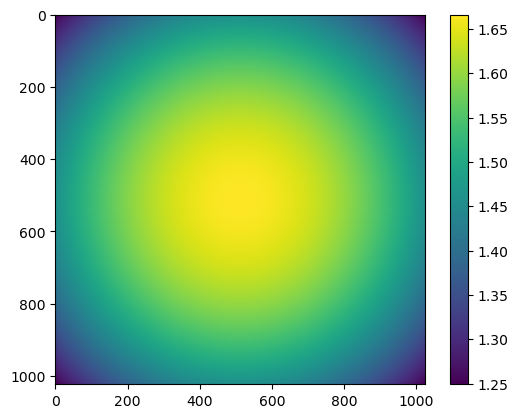

In [3]:
n0 = 1.666
n2 = 1.291**2
length = 1024
width = 1
x = np.linspace(-width/2, width/2, length)
y = np.linspace(-width/2, width/2, length)
xx, yy = np.meshgrid(x,y)
n = n0 - 0.5 * n2 * (xx*xx + yy*yy)
plt.imshow(n)
plt.colorbar()
plt.show()

In [ ]:
params = {}
with open("params1.txt") as f:
    lines = f.readlines()
    for item in lines:
        item = item.split()
        params[item[0]] = float(item[1])
n0 = params['n0_real'] +1j*params["n0_imag"]
n0 = params['n2_real'] +1j*params["n2_imag"]
wavelength = params['wavelength'] / n0
w0 = params['w0']
print(w0)

0.0006773633813521525


In [7]:
import pickle
with open("saved_dict.pkl", "rb") as f:
    load_dict = pickle.load(f)
a2s = sorted(load_dict.keys())
print(a2s)
gammas = {}
for a2 in a2s:
    gamma = np.sqrt(n2/n0 + 1j*(wavelength*a2)/2*np.pi)
    gammas[a2] = gamma
print(gammas)

[-15000.0, -10000.0, -1000.0, 0.0, 10.0, 100.0, 1000.0, 10000.0, 100000.0, 140000.0]
{-15000.0: np.complex128(0.11195961185991704-0.11195961185991704j), -10000.0: np.complex128(0.09141464028561755-0.09141464028561755j), -1000.0: np.complex128(0.028907847478753673-0.028907847478753673j), 0.0: np.complex128(0j), 10.0: np.complex128(0.002890784747875367+0.002890784747875367j), 100.0: np.complex128(0.009141464028561754+0.009141464028561754j), 1000.0: np.complex128(0.028907847478753673+0.028907847478753673j), 10000.0: np.complex128(0.09141464028561755+0.09141464028561755j), 100000.0: np.complex128(0.28907847478753673+0.28907847478753673j), 140000.0: np.complex128(0.3420422640839636+0.3420422640839636j)}


In [8]:
df = pd.DataFrame(columns=["a2", "gamma", "abs_gamma"])
df["a2"] = np.array(list(gammas.keys()))
df["a2"] = df["a2"].apply(lambda x: f"{x:.1e}")
df["gamma"] = gammas.values()
df["abs_gamma"] = np.abs(np.array(list(gammas.values())))
df

,a2,gamma,abs_gamma
0,-1.5e+04,0.111960-0.111960j,0.158335
1,-1.0e+04,0.091415-0.091415j,0.129280
2,-1.0e+03,0.028908-0.028908j,0.040882
3,0.0e+00,0.000000+0.000000j,0.000000
4,1.0e+01,0.002891+0.002891j,0.004088
5,1.0e+02,0.009141+0.009141j,0.012928
6,1.0e+03,0.028908+0.028908j,0.040882
7,1.0e+04,0.091415+0.091415j,0.129280
8,1.0e+05,0.289078+0.289078j,0.408819
9,1.4e+05,0.342042+0.342042j,0.483721


In [112]:
# n0 = 1.6
# n2 = 10000
r = 1e-3
n = n0 - 0.5 * n2 * r*r
print(n)

1.0


5905249.348852994


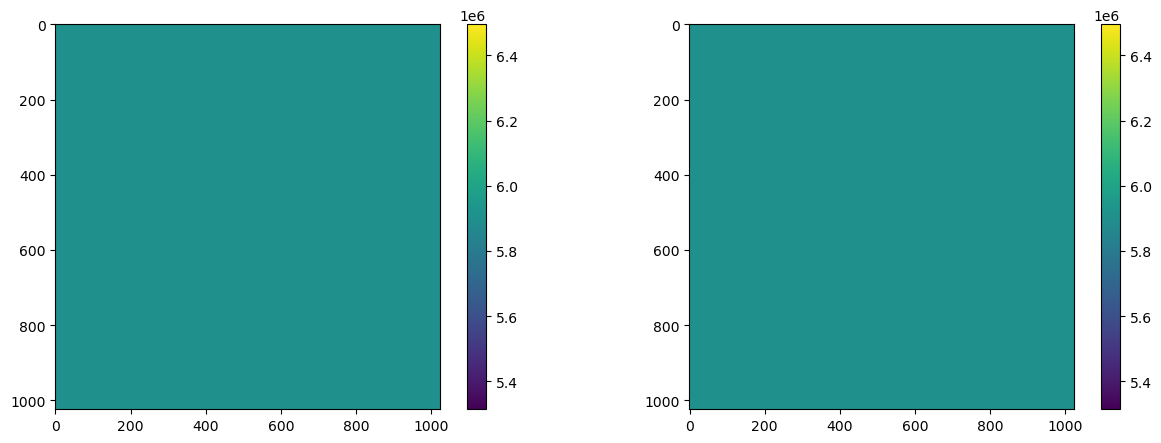

In [113]:
length = 1024
width = 1000e-6
fig, axes = plt.subplots(1,2, figsize=(15,5))
wavenumber = 2 * np.pi / wavelength
print(wavenumber)
x = np.linspace(-width/2, width/2, length)
y = np.linspace(-width/2, width/2, length)
xx, yy = np.meshgrid(x,y)
k = wavenumber * (1 - 0.5 * n2 * (xx*xx + yy*yy) / n0)
# a = np.exp(0.5*n2/n0 * (xx*xx +yy*yy) * k * 1e-3)
im = axes[0].imshow(np.abs(k))
fig.colorbar(im, ax = axes[0])

wavenumber = 2*np.pi / wavelength / n0
n = n0 - 0.5 * n2 * (xx*xx + yy*yy)
k = wavenumber * n
im = axes[1].imshow(k)
fig.colorbar(im, ax = axes[1])
plt.show()

In [114]:
# Gives w0 from angle and wavelength
# n0 = 1
# wavelength = 1064e-9
angle = 0.5e-3 #2 * np.pi / 180.0 / n0
w_0 = wavelength / (np.pi * np.tan(angle))
print(w_0)

0.0006773633813521525


In [115]:
wavelength / (np.pi * np.tan(angle)*np.tan(angle))

np.float64(1.354726649810406)

In [116]:
np.sqrt(0.4445894883088606 * 1e-3 * wavelength / np.pi)

np.float64(1.2270873322837203e-05)

In [117]:
np.pi * w0*w0 / wavelength

1.354726649810406

<Axes: >

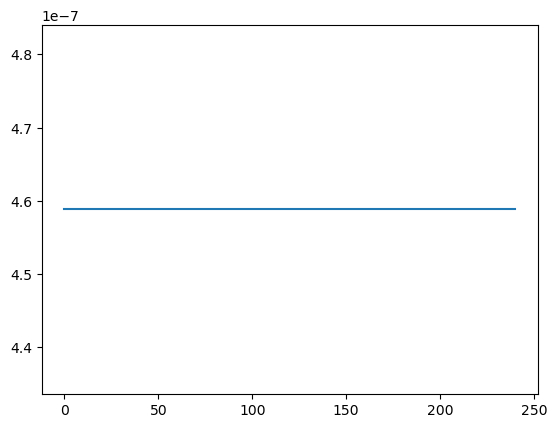

In [118]:
df = pd.read_csv("output.csv")
df["beam waist"].plot()
# df["beam waist"].plot()

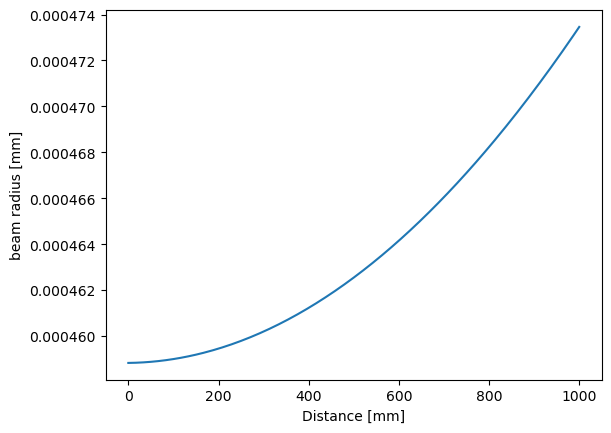

In [119]:
df = pd.read_csv("output.csv")
plt.plot(np.linspace(0, 1, df.index.size)*1000, df["beam radius"]*1000)
plt.ylabel("beam radius [mm]")
plt.xlabel("Distance [mm]")
plt.show()
# df["beam waist"].plot()

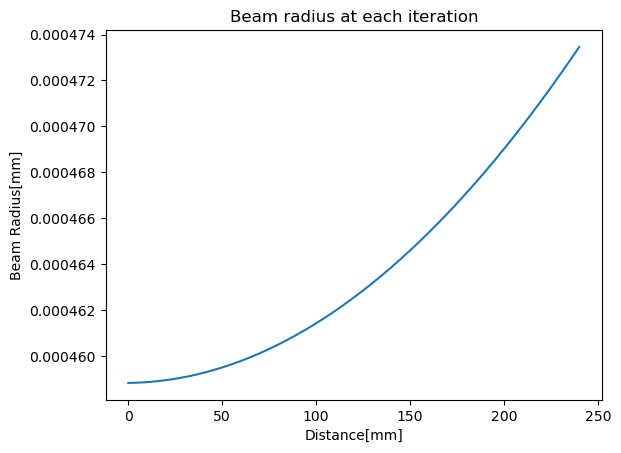

In [120]:
q_real = df["q param real"]
q_imag = df["q param imag"]
radius = (wavelength / np.pi) * (q_imag + (q_real*q_real)/q_imag)
# radius = (500e-9 / np.pi) * q_imag
# print(radius)
plt.plot(np.arange(0, df.index.size, 1), radius*1e3)
plt.ylabel("Beam Radius[mm]")
plt.xlabel("Distance[mm]")
plt.title("Beam radius at each iteration")
plt.show()

In [121]:
q_real = 0.001666152303400
q_imag = 0.000020854040332
# (500e-9 / np.pi) * ((q_imag + (q_real*q_real))/q_imag)
np.pi

3.141592653589793

0.11697783979216492 [511 511] [312 495]


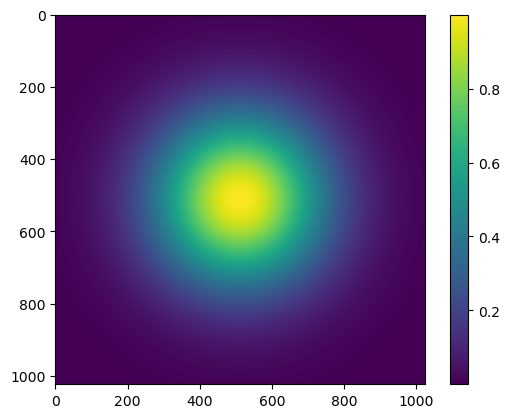

In [122]:
wSG = 0.0997186335
width = 0.3
length = 1024
x = np.linspace(-width/2, width/2, length)
y = np.linspace(-width/2, width/2, length)
xx, yy = np.meshgrid(x,y)
k = 2*np.pi/wavelength
R = 2.0385672164

E = np.exp(-(xx*xx + yy*yy)/(wSG*wSG))
E = E*np.exp(-1j*k*(xx*xx+yy*yy)/(2*R))
Y = np.abs(E)**2
half_max = np.max(Y) / 2.0
maxIndex = np.array(np.unravel_index(np.argmax(Y), Y.shape))
left_idx = np.array(np.unravel_index(np.argmax(Y > half_max), Y.shape))
fwhm=(np.sqrt(np.sum((maxIndex - left_idx)**2)))*2 * width/length
print(fwhm, maxIndex, left_idx)
plt.imshow(Y)
plt.colorbar()
plt.show()

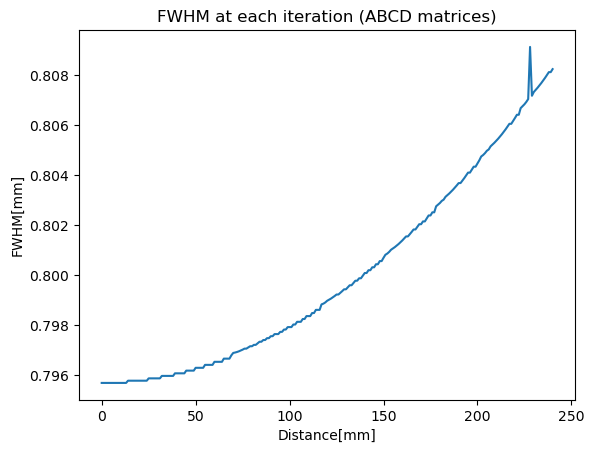

In [123]:
fwhm = []
length = pow(2,10)
width = 1000e-6
x = np.linspace(-width/2, width/2, length)
y = np.linspace(-width/2, width/2, length)
xx, yy = np.meshgrid(x,y)
# y = np.linspace(-width/2, width/2, length)
for i in range(0,df.index.size):
    q_real = df.iloc[i]["q param real"]
    q_imag = df.iloc[i]["q param imag"]
    q = q_real + 1j*q_imag
    qr = 1/((1/q).real)
    qi = -1/((1/q).imag)
    Y = np.abs((1/(q)) * np.exp((-1j * k * (xx*xx + yy*yy)/(2*qr)) - (k*(xx*xx + yy*yy)/(2*qi))))**2     # FWHM 2D
    # Y = np.abs((1/(q)) * np.exp(-1j * k * (q_real - 0.002 + ((xx*xx + yy*yy) / (2 * (q))))))**2     # FWHM 2D
    # Y = np.abs((1/(q)) * np.exp(-1j * k * (q_real + ((x*x) / (2 * (q))))))**2             # FWHM 1D
    half_max = np.max(Y) / 2.0
    maxIndex = np.array(np.unravel_index(np.argmax(Y), Y.shape))
    #find when function crosses line half_max (when sign of diff flips)
    #take the 'derivative' of signum(half_max - Y[])
    # d = np.sign(half_max - np.array(Y[0:-1])) - np.sign(half_max - np.array(Y[1:]))
    #plot(X[0:len(d)],d) #if you are interested
    #find the left and right most indexes
    left_idx = np.array(np.unravel_index(np.argmax(Y > half_max), Y.shape))
    # dist = (maxIndex - left_idx)**2
    fwhm.append((np.sqrt(np.sum((maxIndex - left_idx)**2)))*2 * width/length) #return the difference (full width)
fwhm = np.array(fwhm)*1e3
plt.plot(np.arange(0, df.index.size, 1), fwhm)
plt.ylabel("FWHM[mm]")
plt.xlabel("Distance[mm]")
plt.title("FWHM at each iteration (ABCD matrices)")
plt.show()


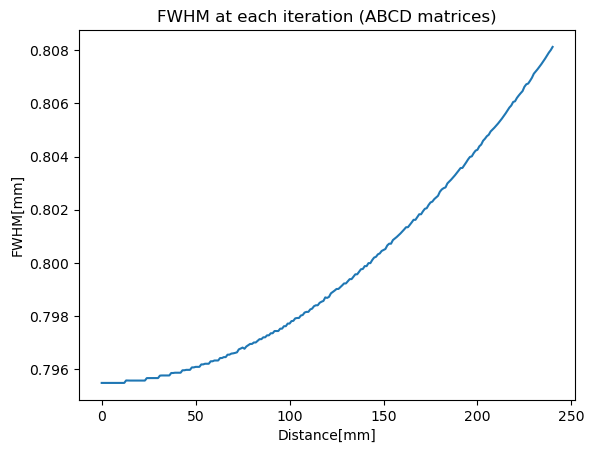

In [124]:
fwhm_refined = []
length = pow(2,10)
width = 1000e-6
x = np.linspace(-width/2, width/2, length)
y = np.linspace(-width/2, width/2, length)
xx, yy = np.meshgrid(x,y)
# y = np.linspace(-width/2, width/2, length)
for i in range(0,df.index.size):
    q_real = df.iloc[i]["q param real"]
    q_imag = df.iloc[i]["q param imag"]
    q = q_real + 1j*q_imag
    qr = 1/((1/q).real)
    qi = -1/((1/q).imag)
    Y = np.abs((1/(q)) * np.exp((-1j * k * (xx*xx + yy*yy)/(2*qr)) - (k*(xx*xx + yy*yy)/(2*qi))))**2     # FWHM 2D
    # Y = np.abs((1/(q)) * np.exp(-1j * k * (q_real - 0.002 + ((xx*xx + yy*yy) / (2 * (q))))))**2     # FWHM 2D
    # Y = np.abs((1/(q)) * np.exp(-1j * k * (q_real + ((x*x) / (2 * (q))))))**2             # FWHM 1D
    half_max = np.max(Y) / 2.0
    maxIndex = np.array(np.unravel_index(np.argmax(Y), Y.shape))
    #find when function crosses line half_max (when sign of diff flips)
    #take the 'derivative' of signum(half_max - Y[])
    # d = np.sign(half_max - np.array(Y[0:-1])) - np.sign(half_max - np.array(Y[1:]))
    #plot(X[0:len(d)],d) #if you are interested
    #find the left and right most indexes
    left_idx = np.array(np.unravel_index(np.argmax(Y > half_max), Y.shape))
    # dist = (maxIndex - left_idx)**2
    fwhm_temp = (np.sqrt(np.sum((maxIndex - left_idx)**2)))*2 * width/length
    fwhm_refined_temp = 1000
    for iter in range(10): 
        width_refined = 1.5*fwhm_temp
        x_refined = np.linspace(-width_refined/2, width_refined/2, length)
        y_refined = np.linspace(-width_refined/2, width_refined/2, length)
        xx_refined, yy_refined = np.meshgrid(x_refined,y_refined)
        Y = np.abs((1/(q)) * np.exp((-1j * k * (xx_refined*xx_refined + yy_refined*yy_refined)/(2*qr)) - (k*(xx_refined*xx_refined + yy_refined*yy_refined)/(2*qi))))**2
        half_max = np.max(Y) / 2.0
        maxIndex = np.array(np.unravel_index(np.argmax(Y), Y.shape))
        left_idx = np.array(np.unravel_index(np.argmax(Y > half_max), Y.shape))
        fwhm_refined_temp = (np.sqrt(np.sum((maxIndex - left_idx)**2)))*2 * width_refined/length
        if np.abs(fwhm_temp - fwhm_refined_temp)/fwhm_refined_temp < 0.0001:
            # print(iter)
            break
        else:
            # print(iter, np.abs(fwhm_temp - fwhm_refined_temp)/fwhm_refined_temp)
            fwhm_temp = fwhm_refined_temp
            
    fwhm_refined.append(fwhm_refined_temp) #return the difference (full width)
fwhm_refined = np.array(fwhm_refined)*1e3
plt.plot(np.arange(0, df.index.size, 1), fwhm_refined)
plt.ylabel("FWHM[mm]")
plt.xlabel("Distance[mm]")
plt.title("FWHM at each iteration (ABCD matrices)")
plt.show()


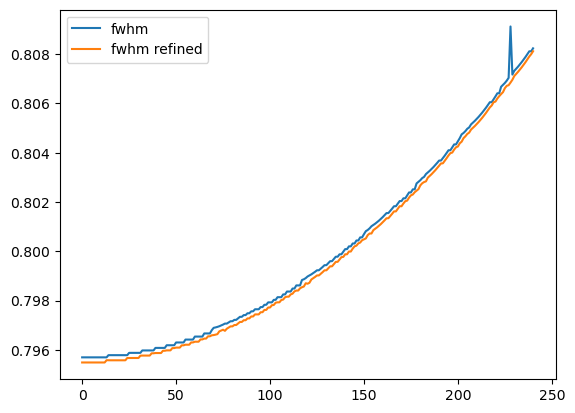

In [125]:
plt.plot(fwhm, label='fwhm')
plt.plot(fwhm_refined, label='fwhm refined')
plt.legend()
plt.show()

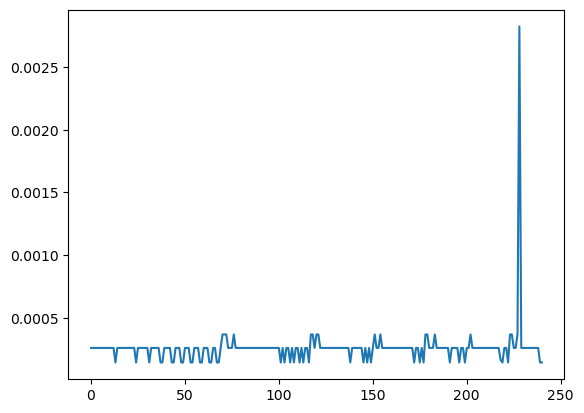

In [126]:
plt.plot(np.abs(fwhm - fwhm_refined)/fwhm_refined)
plt.show()

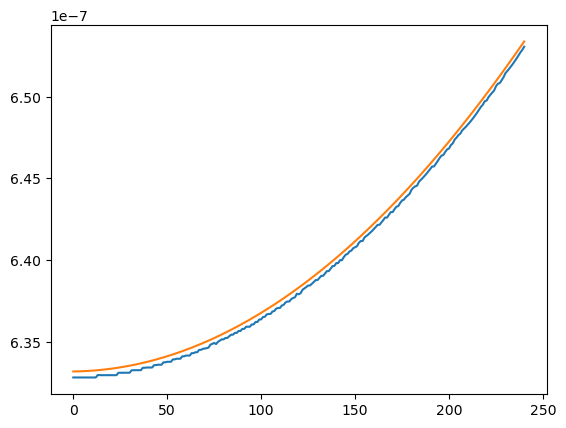

In [127]:
plt.plot((fwhm_refined/1e3)**2)
plt.plot(df["beam radius"]*1.38)
plt.show()

In [87]:
np.mean(fwhm_refined**2 / (df["beam radius"]*1e6))

np.float64(1.3792065771697062)

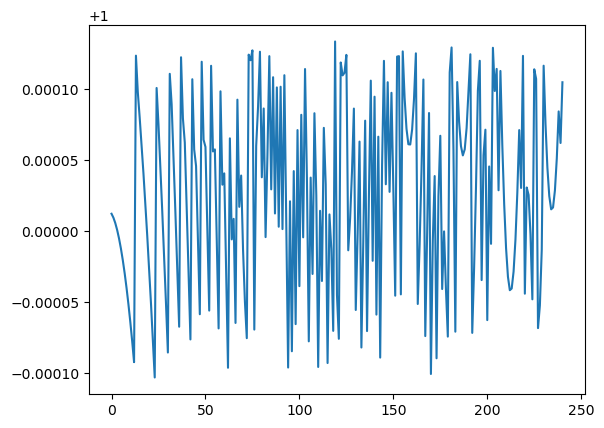

In [128]:
plt.plot(fwhm_refined**2 / (df["beam radius"]*1.37918e6))
plt.show()

In [23]:
print(np.array(fwhm).shape)
# print(np.array(fwhm)/np.sqrt(2))

(161,)


In [24]:
fwhm_1D = np.array([0.08251953, 0.12353516, 0.16455078, 0.20556641, 0.24658203, 0.28759766, 0.32861328, 0.36962891, 0.41064453, 0.45166016, 0.49267578])
fwhm_2D = np.array([0.08272729, 0.12358243, 0.16456889, 0.20559482, 0.24664052, 0.28771742, 0.32878881, 0.36986394, 0.41096054, 0.45204112, 0.493144])
fwhm_2D_1_6 = np.array([0.06743233, 0.09767578, 0.12943782, 0.1618621, 0.19415674, 0.22669716, 0.25905978, 0.29154602, 0.32397157, 0.3563744, 0.38891226])
# fwhm, UGB, n0=1.6, n2=0.01, modified k with k*n
# [0.065089,0.0974429,0.130897,0.163177,0.195785,0.22766,0.261273,0.293756,0.328024,0.368242,0.39357]
# fwhm_2D_gaussian = np.array([0.06743233 0.09730405 0.12844674 0.1594042  0.18872686 0.21735921 0.24464011 0.27023798 0.29424202 0.31655692 0.3366238 ])
# fwhm from ugblocks code with ABS(val-max*0.5)
fwhm_ugb_05 = np.array([0.118746,0.176777,0.232497,0.288842,0.350631,0.404434,0.463056,0.519996,0.577895,0.635593,0.693524])

In [19]:
file = open("/home/karthik/Desktop/FAU/Thesis/UGBlocks_V4_Oct_21_2025/program2D/para.dat", 'r')
params_ugb = list(map(float, file.read().split()))
print(params_ugb)

[10.0, 0.0, 5.0, 1.0, 2.0, 1.0, 1.0, 0.0, 16.0, 1.0]


In [20]:
mape = {}
smape = {}
mae = {}
maxPE = {}

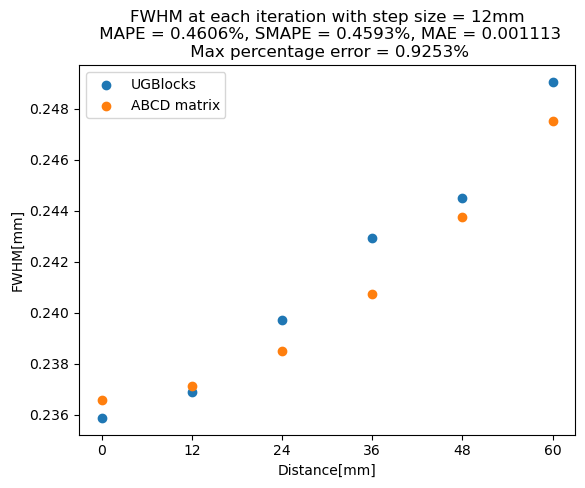

In [64]:
# fwhm_ugb = np.array([0.0820841,0.121976,0.166244,0.203626,0.243607,0.285258,0.328429,0.368583,0.409361,0.450372,0.49066])
# fwhm_ugb = np.loadtxt('/home/karthik/Desktop/FAU/Thesis/UGBlocks_V4_Oct_21_2025/program2D/fwhm.csv', delimiter=',', dtype=float)
fwhm_ugb = np.loadtxt('/home/karthik/FAUbox/thesis/fwhm.csv', delimiter=',', dtype=float)
# file = open("/home/karthik/Desktop/FAU/Thesis/UGBlocks_V4_Oct_21_2025/program2D/para.dat", 'r')
file = open("/home/karthik/FAUbox/thesis/para.dat", 'r')
params_ugb = list(map(float, file.read().split()))
end = params["propagation_length"]*(params["iterations"]+1) * 1000
# step = params["propagation_length"] * 1000
step = int(params_ugb[2])
plt.scatter(np.arange(0, end, step), fwhm_ugb[0::1], label="UGBlocks")
plt.scatter(np.arange(0, end, step), fwhm_refined[0::step], label="ABCD matrix")
mape[step] = 100 * np.mean(np.abs(fwhm_ugb - fwhm_refined[0::step]) / fwhm_refined[0::step])
smape[step] = 200 * np.mean(np.abs(fwhm_ugb - fwhm_refined[0::step]) / (np.abs(fwhm_ugb) + np.abs(fwhm_refined[0::step])))
mae[step] = np.mean(np.abs(fwhm_ugb - fwhm_refined[0::step]))
maxPE[step] = 100 * np.max(np.abs(fwhm_ugb - fwhm_refined[0::step]) / fwhm_refined[0::step])
plt.ylabel("FWHM[mm]")
plt.xlabel("Distance[mm]")
plt.xticks(np.arange(0, end, step))
plt.title(f"FWHM at each iteration with step size = {step}mm\n MAPE = {mape[step]:.4f}%, SMAPE = {smape[step]:.4f}%, MAE = {mae[step]:.6f}\n Max percentage error = {maxPE[step]:.4f}%")
plt.legend()
plt.show()

In [130]:
fwhm_refined[60] - fwhm_refined[0]

np.float64(0.0008431025258809344)

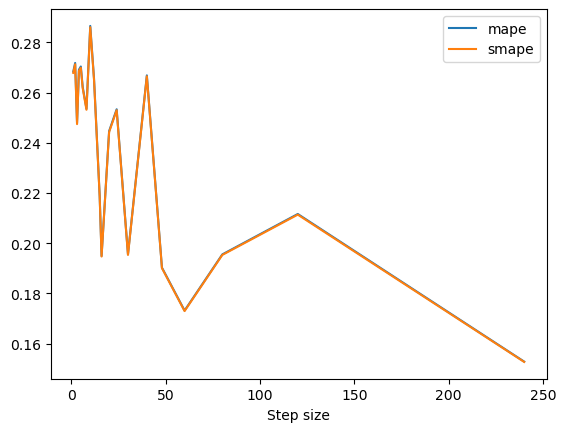

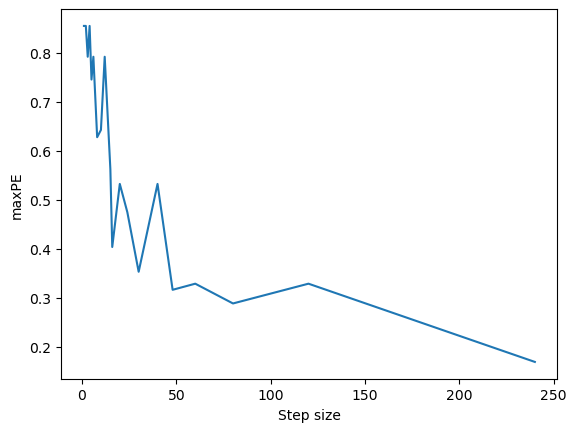

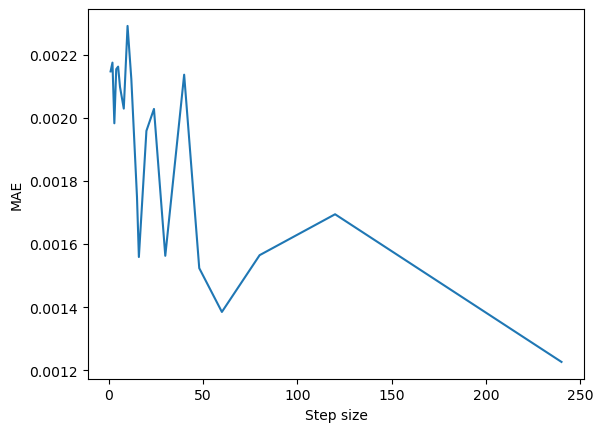

In [229]:
lists = sorted(mape.items())
x, y = zip(*lists)
plt.plot(x, y, label = "mape")
lists = sorted(smape.items())
x, y = zip(*lists)
plt.plot(x, y, label = "smape")
plt.legend()
plt.xlabel("Step size")
plt.show()

lists = sorted(maxPE.items())
x, y = zip(*lists)
plt.plot(x, y)
plt.xlabel("Step size")
plt.ylabel("maxPE")
plt.show()

lists = sorted(mae.items())
x, y = zip(*lists)
plt.plot(x, y)
plt.xlabel("Step size")
plt.ylabel("MAE")
plt.show()

In [146]:
factors = []
for i in range(1, 120):
    if 240 % i == 0:
        factors.append(i)
print(factors)

[1, 2, 3, 4, 5, 6, 8, 10, 12, 15, 16, 20, 24, 30, 40, 48, 60, 80]


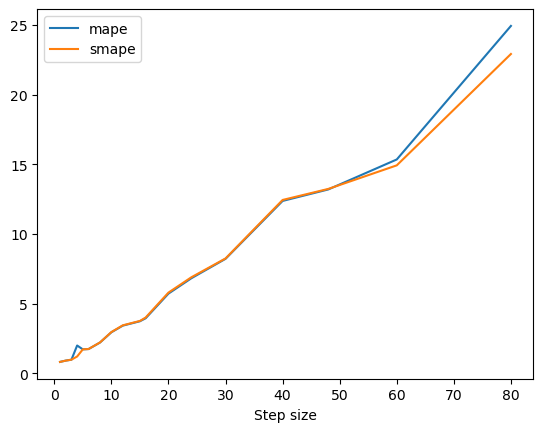

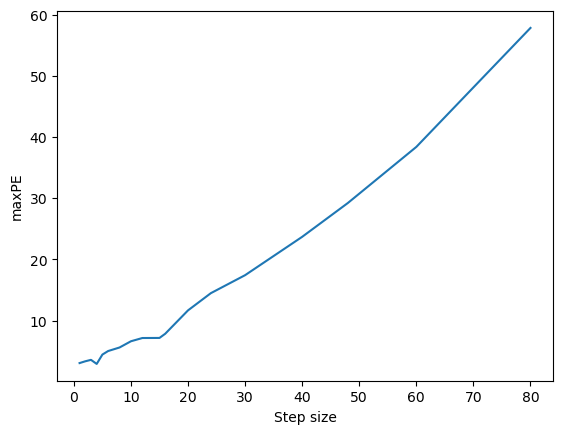

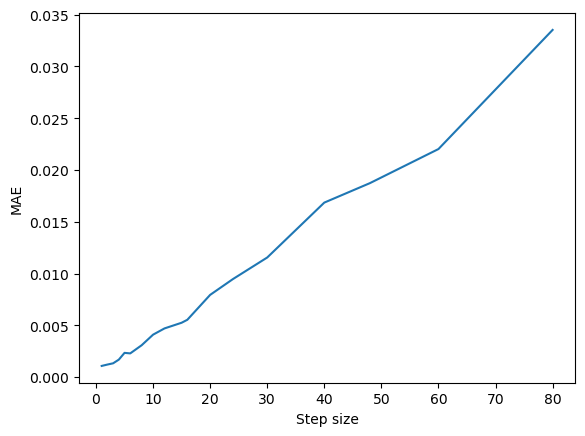

In [164]:
step_size = [1,2,3,4,5,6,8,10,12,15,16,20,24,30,40,48,60,80]
mape = [0.81599999999999995,0.90990000000000004,0.97509999999999997,1.994,1.7162999999999999,1.7386999999999999,2.2050999999999998,2.9432999999999998,3.4211999999999998,3.7347999999999999,3.9489999999999998,5.7196999999999996,6.8204000000000002,8.2180999999999997,12.3752,13.199999999999999,15.352600000000001,24.941800000000001]
smape = [0.81520000000000004,0.9093,0.97550000000000003,1.2049000000000001,1.7181,1.7415,2.2134999999999998,2.9601000000000002,3.4436,3.7581000000000002,4.0026000000000002,5.7935999999999996,6.8912000000000004,8.2464999999999993,12.445600000000001,13.238099999999999,14.930099999999999,22.9268]
mae = [0.0010839999999999999,0.0012160000000000001,0.0013370000000000001,0.0016919999999999999,0.0023449999999999999,0.002294,0.003081,0.0041019999999999997,0.004705,0.0052529999999999999,0.0055380000000000004,0.0079439999999999997,0.0094730000000000005,0.011553000000000001,0.016854999999999998,0.018735999999999999,0.022024999999999999,0.033528000000000002]
maxPE = [3.0579999999999998,3.3500000000000001,3.5851999999999999,2.9192,4.4488000000000003,5.0259999999999998,5.6059000000000001,6.6239999999999997,7.1551999999999998,7.1681999999999997,7.8483999999999998,11.6752,14.489599999999999,17.431000000000001,23.701499999999999,29.2301,38.404800000000002,57.860500000000002]
plt.plot(step_size, mape, label = 'mape')
plt.plot(step_size, smape, label = "smape")
plt.xlabel("Step size")
plt.legend()
plt.show()
plt.plot(step_size, maxPE)
plt.xlabel("Step size")
plt.ylabel("maxPE")
plt.show()
plt.plot(step_size, mae)
plt.xlabel("Step size")
plt.ylabel("MAE")
plt.show()

In [408]:
fwhm_ugb = np.loadtxt('/home/karthik/Desktop/FAU/Thesis/UGBlocks_V4_Oct_21_2025/program2D/fwhm.csv', delimiter=',', dtype=float)
print("{:.10f}".format(fwhm_refined[-1] - fwhm_ugb[-1]))

0.0081630010


In [403]:
fwhm_refined[-1]

np.float64(0.2736870010005276)

In [410]:
error_df

,n2,FWHM,E80_4,E80_2,E80_1,E80_4_FWHM,E80_2_FWHM,E80_1_FWHM
0,0.005,0.273687,0.025247,0.025247,0.008163,0.092248,0.092248,0.029826
1,0.010,0.393803,0.014840,0.002121,0.002335,0.037683,0.005386,0.005929
2,0.020,0.249816,0.039996,0.014906,0.005210,0.160102,0.059668,0.020855
3,0.040,0.138018,0.050687,0.013599,0.001504,0.367250,0.098531,0.010898


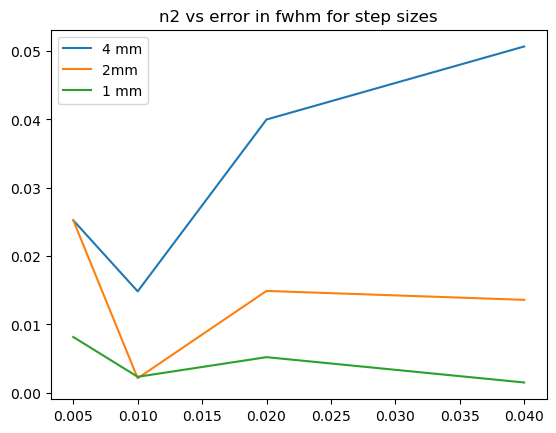

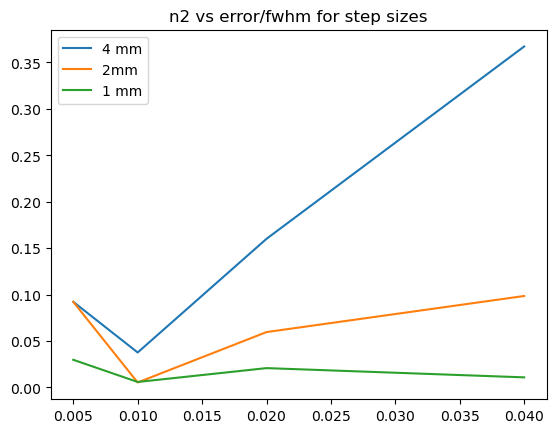

In [413]:
error_df = pd.read_csv("accuracies_n2.csv")
n2s = error_df["n2"]
fwhms = error_df["FWHM"]
E80_4 = error_df["E80_4"]
E80_2 = error_df["E80_2"]
E80_1 = error_df["E80_1"]
E80_4_FWHM = error_df["E80_4_FWHM"]
E80_2_FWHM = error_df["E80_2_FWHM"]
E80_1_FWHM = error_df["E80_1_FWHM"]

plt.plot(n2s, E80_4, label = "4 mm")
plt.plot(n2s, E80_2, label = "2mm")
plt.plot(n2s, E80_1, label = "1 mm")
plt.legend()
plt.title("n2 vs error in fwhm for step sizes")
plt.show()

plt.plot(n2s, E80_4_FWHM, label = "4 mm")
plt.plot(n2s, E80_2_FWHM, label = "2mm")
plt.plot(n2s, E80_1_FWHM, label = "1 mm")
plt.legend()
plt.title("n2 vs error/fwhm for step sizes")
plt.show()

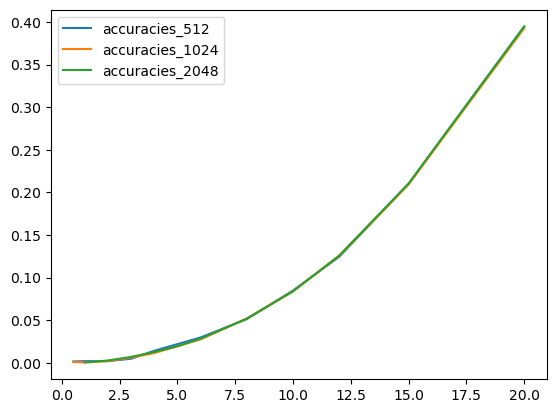

In [57]:
error_df = pd.read_csv("gaussian duct step size vs accuracies.csv")
z = error_df["step size"]
accuracies_1024 = error_df["accuracies_1024"]
accuracies_512 = error_df["accuracies_512"]
accuracies_2048 = error_df["accuracies_2048"]
plt.plot(z[1:], np.abs(accuracies_512[1:]), label="accuracies_512")
plt.plot(z[1:], np.abs(accuracies_1024[1:]), label="accuracies_1024")
plt.plot(z[1:], np.abs(accuracies_2048[1:]), label="accuracies_2048")
plt.legend()
plt.show()

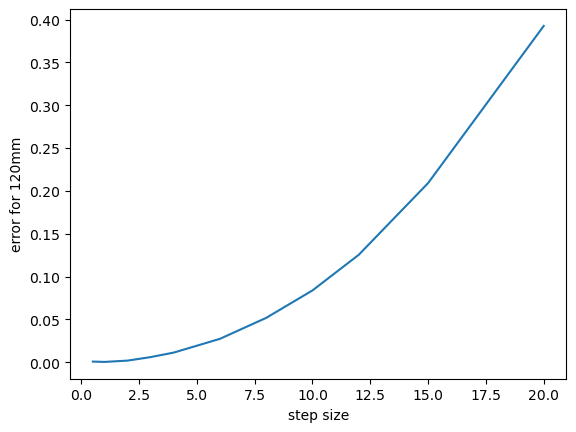

In [23]:
z = np.array([20, 15, 12, 10, 8, 6, 5, 4, 3, 2, 1, 0.5])
errors = np.array([-0.3925956928, -0.2091886928, -0.1254156928, -0.0838586928, -0.0518526928, -0.0273732928, -0.0193133928, -0.0112969928, -0.0060160928, -0.0019113928, 0.0003878072, -0.0007707928])
plt.plot(z, np.abs(errors))
plt.xlabel('step size')
plt.ylabel('error for 120mm')
plt.show()

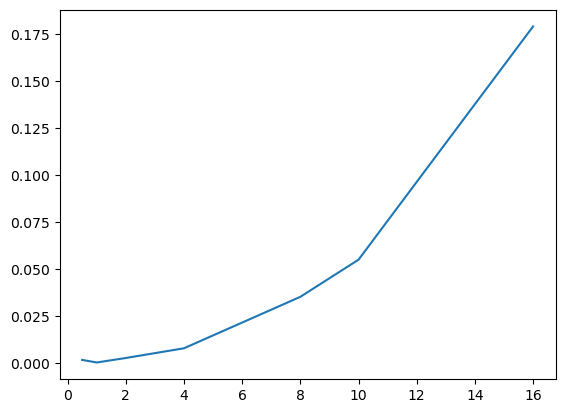

In [104]:
z = np.array([16, 10, 8, 4, 2, 1, 0.5]) 
errors = np.array([0.1791068, 0.0549058532, 0.0351348, 0.0077317, 0.0025622, 0.0001754, 0.0015487])
plt.plot(z, errors)
plt.show()

In [2]:
# Plotting electric field

"""A_0*q_0 = 1"""

width = 1000e-6
x = np.linspace(-width/2, width/2, 100)
y = np.linspace(-width/2, width/2, 100)
xx, yy = np.meshgrid(x,y)
k = 2*np.pi/wavelength

fig, axes = plt.subplots(5, 5)
fig.set_figheight(25)
fig.set_figwidth(25)
plt.suptitle("Electric fields")

q_real = df.iloc[0]["q param real"]
q_imag = df.iloc[0]["q param imag"]
q = q_real + 1j*q_imag
# E = (1/(q)) * np.exp(-1j * k * (q_real + ((xx*xx + yy*yy) / (2 * (q)))))
qr = 1/((1/q).real)
qi = -1/((1/q).imag)
print(qr, np.sqrt(2*qi/k)*1e6)
E = (1/(q)) * np.exp((-1j * k * (xx*xx + yy*yy)/(2*qr)) - (k*(xx*xx + yy*yy)/(2*qi)))    # FWHM 2D
axes[0, 0].imshow(np.abs(E)**2)
for i in range(1,df.index.size):
    q_real = df.iloc[i]["q param real"]
    q_imag = df.iloc[i]["q param imag"]
    q = q_real + 1j*q_imag
    qr = 1/((1/q).real)
    qi = -1/((1/q).imag)
    E = (1/(q)) * np.exp((-1j * k * (xx*xx + yy*yy)/(2*qr)) - (k*(xx*xx + yy*yy)/(2*qi)))    # FWHM 2D

    # E = (1/(q)) * np.exp(-1j * k * (q_real + ((xx*xx + yy*yy) / (2 * (q)))))
    axes[(i+4)//5, (i-1)%5].imshow(np.abs(E)**2)

NameError: name 'wavelength' is not defined

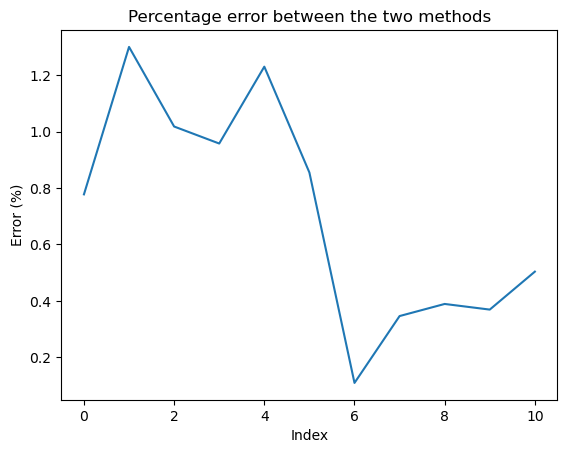

In [31]:
plt.plot(np.abs(fwhm_ugb - fwhm)/fwhm * 100)
plt.ylabel("Error (%)")
plt.xlabel("Index")
plt.title("Percentage error between the two methods")
plt.show()

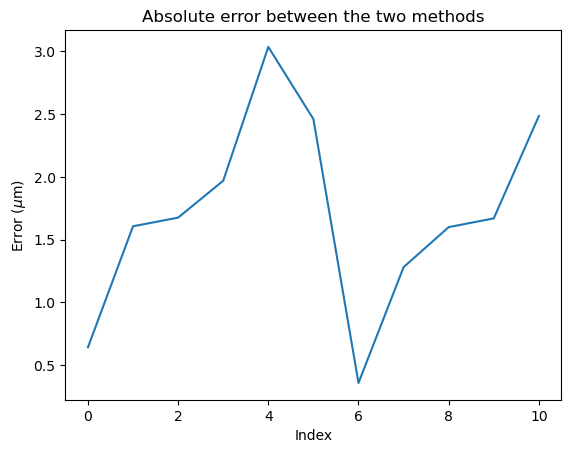

In [39]:
plt.plot(np.abs(fwhm_ugb - fwhm)*1000)
plt.ylabel(r"Error ($\mu$m)")
plt.xlabel("Index")
plt.title("Absolute error between the two methods")
plt.show()

In [93]:
# Test with quadratic function 4 - (x^2 + y^2). Max = 4, Halfmax = 2, fwhm = 2*sqrt(2) = 2.8284271247461903
# length = 1024
diff = []
for i in range(9, 14):
    length = 2**i
    width = 4
    x = np.linspace(-width/2, width/2, length)
    y = np.linspace(-width/2, width/2, length)
    xx, yy = np.meshgrid(x,y)

    F = 4 - xx*xx - yy*yy   # 2D
    # plt.imshow(F)

    # F = 4 - x*x             # 1D
    # plt.plot(F)

    # plt.show()

    half_max = np.max(F) / 2.0
    maxIndex = np.array(np.unravel_index(np.argmax(F), F.shape))
    #find when function crosses line half_max (when sign of diff flips)
    #take the 'derivative' of signum(half_max - Y[])
    # d = np.sign(half_max - np.array(Y[0:-1])) - np.sign(half_max - np.array(Y[1:]))
    #plot(X[0:len(d)],d) #if you are interested
    #find the left and right most indexes
    left_idx = np.array(np.unravel_index(np.argmax(F > half_max), F.shape))
    # dist = (maxIndex - left_idx)**2
    fwhm = (np.sqrt(np.sum((maxIndex - left_idx)**2)))*2 * width/length #return the difference (full width)

    # print(f"Max: {np.max(F)}, Half Max: {half_max}, FWHM: {fwhm}")
    diff.append(np.sqrt(8) - fwhm)
    # print(f"Difference = {diff}, Percentage difference = {perc_diff}")
perc_diff = (diff / np.sqrt(8) * 100)


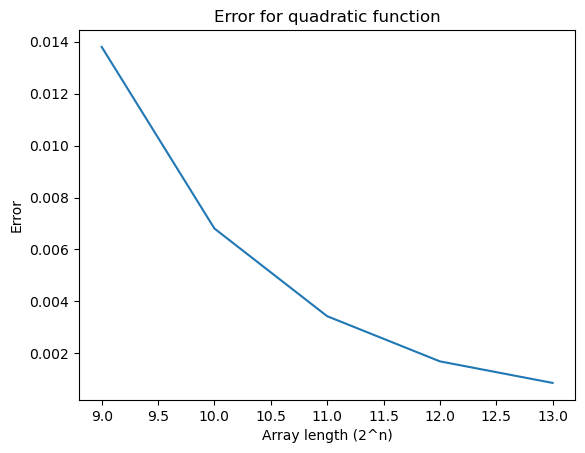

In [96]:
plt.plot(range(9, 14), np.array(diff))
plt.xlabel("Array length (2^n)")
plt.ylabel("Error")
plt.title("Error for quadratic function")
plt.show()

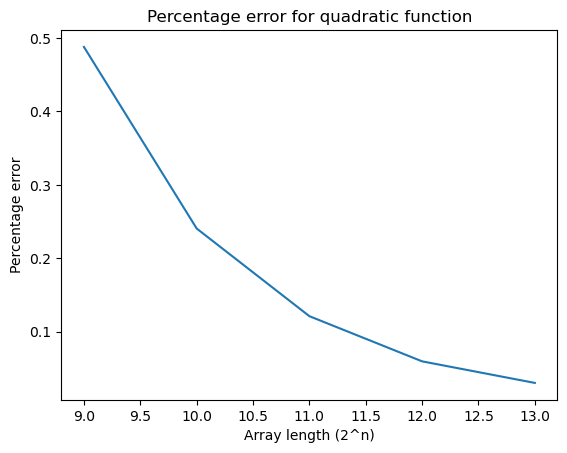

In [97]:
plt.plot(range(9, 14), np.array(perc_diff))
plt.xlabel("Array length (2^n)")
plt.ylabel("Percentage error")
plt.title("Percentage error for quadratic function")
plt.show()

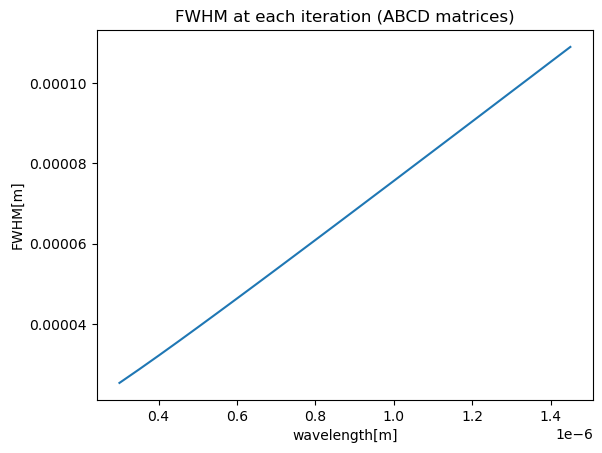

In [3]:
wavelengths = np.arange(300, 1500, 50) * 1e-9
beam_radii = []
w0 = 1e-5
q_real = 2e-3
fwhm_refined = []
for wavelength in wavelengths:
    q_imag = np.pi * w0*w0 / wavelength
    beam_radii.append(wavelength / np.pi * (q_imag + (q_real**2) / q_imag))
    length = pow(2,10)
    width = 1000e-6
    x = np.linspace(-width/2, width/2, length)
    y = np.linspace(-width/2, width/2, length)
    xx, yy = np.meshgrid(x,y)
    # y = np.linspace(-width/2, width/2, length)
    k = 2 * np.pi / wavelength
    q = q_real + 1j*q_imag
    qr = 1/((1/q).real)
    qi = -1/((1/q).imag)
    Y = np.abs((1/(q)) * np.exp((-1j * k * (xx*xx + yy*yy)/(2*qr)) - (k*(xx*xx + yy*yy)/(2*qi))))**2     # FWHM 2D
    # Y = np.abs((1/(q)) * np.exp(-1j * k * (q_real - 0.002 + ((xx*xx + yy*yy) / (2 * (q))))))**2     # FWHM 2D
    # Y = np.abs((1/(q)) * np.exp(-1j * k * (q_real + ((x*x) / (2 * (q))))))**2             # FWHM 1D
    half_max = np.max(Y) / 2.0
    maxIndex = np.array(np.unravel_index(np.argmax(Y), Y.shape))
    #find when function crosses line half_max (when sign of diff flips)
    #take the 'derivative' of signum(half_max - Y[])
    # d = np.sign(half_max - np.array(Y[0:-1])) - np.sign(half_max - np.array(Y[1:]))
    #plot(X[0:len(d)],d) #if you are interested
    #find the left and right most indexes
    left_idx = np.array(np.unravel_index(np.argmax(Y > half_max), Y.shape))
    # dist = (maxIndex - left_idx)**2
    fwhm_temp = (np.sqrt(np.sum((maxIndex - left_idx)**2)))*2 * width/length
    fwhm_refined_temp = 1000
    for iter in range(10): 
        width_refined = 1.5*fwhm_temp
        x_refined = np.linspace(-width_refined/2, width_refined/2, length)
        y_refined = np.linspace(-width_refined/2, width_refined/2, length)
        xx_refined, yy_refined = np.meshgrid(x_refined,y_refined)
        Y = np.abs((1/(q)) * np.exp((-1j * k * (xx_refined*xx_refined + yy_refined*yy_refined)/(2*qr)) - (k*(xx_refined*xx_refined + yy_refined*yy_refined)/(2*qi))))**2
        half_max = np.max(Y) / 2.0
        maxIndex = np.array(np.unravel_index(np.argmax(Y), Y.shape))
        left_idx = np.array(np.unravel_index(np.argmax(Y > half_max), Y.shape))
        fwhm_refined_temp = (np.sqrt(np.sum((maxIndex - left_idx)**2)))*2 * width_refined/length
        if np.abs(fwhm_temp - fwhm_refined_temp)/fwhm_refined_temp < 0.0001:
            # print(iter)
            break
        else:
            # print(iter, np.abs(fwhm_temp - fwhm_refined_temp)/fwhm_refined_temp)
            fwhm_temp = fwhm_refined_temp
            
    fwhm_refined.append(fwhm_refined_temp) #return the difference (full width)
plt.plot(wavelengths, fwhm_refined)
plt.ylabel("FWHM[m]")
plt.xlabel("wavelength[m]")
plt.title("FWHM at each iteration (ABCD matrices)")
plt.show()


In [27]:
a = 1.3791775540976843
np.sqrt(a)

np.float64(1.1743839040525395)

1.3791775540976843


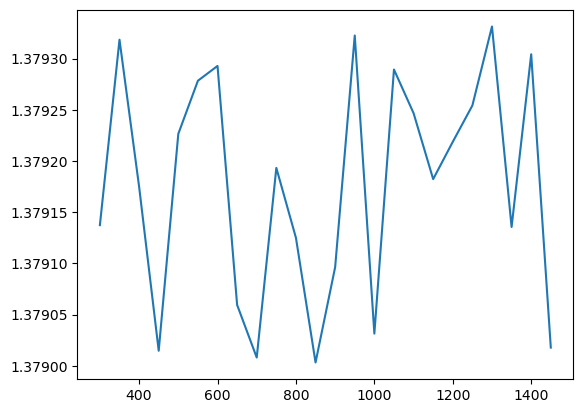

In [12]:
print(np.mean(np.array(fwhm_refined)**2 / np.array(beam_radii)))
plt.plot(wavelengths*1e9,np.array(fwhm_refined)**2 / np.array(beam_radii))
plt.show()

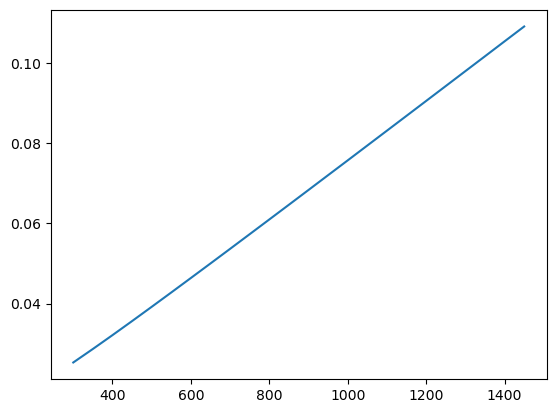

In [6]:
plt.plot(wavelengths*1e9, np.array(fwhm_refined)*1e3)
plt.show()